# CONVOLUTIONAL NN

In [1]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#load the dataset
(x_train,y_train),(x_test,y_test)=mnist.load_data()

#display dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


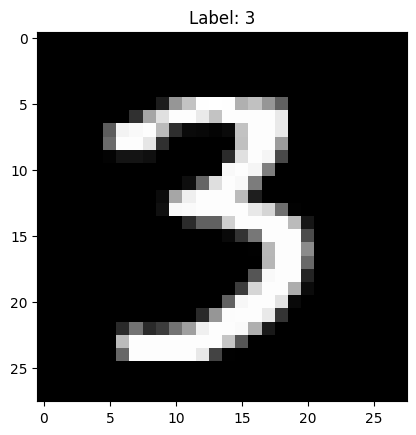

In [3]:
#Basic data visualization
img=x_train[10000,:,:]
label=y_train[10000]
plt.imshow(img,cmap='gray')
plt.title(f"Label: {label}")
plt.show()

# Data Preprocessing

Normalize the data and reshape it for CNN input

In [4]:
#normalize and rshape
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float')/255

#one-hot encode labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

# Model Buliding

Build a CNN model using Keras Sequential API.

In [5]:
model=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)), #convolutional layers->detects patterns
    MaxPooling2D(pool_size=(2,2)),#pooling layer->reduces spatial dimensions
    Conv2D(64,kernel_size=(3,3),activation='relu'), #convolutional layers->detects patterns
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

C:\Users\spoor\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Model compilation

compile the model with adam optimizer and categorical crossentropy loss.

In [6]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# Model training

train the model on the training data

In [7]:
history=model.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)
#epochs-> model sees dataset 5 items
#batch_size->processes 128 images per step
#validation_split->uses 20% of training data for validation

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9312 - loss: 0.2341 - val_accuracy: 0.9771 - val_loss: 0.0795
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9804 - loss: 0.0622 - val_accuracy: 0.9808 - val_loss: 0.0669
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9866 - loss: 0.0440 - val_accuracy: 0.9837 - val_loss: 0.0573
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9895 - loss: 0.0325 - val_accuracy: 0.9871 - val_loss: 0.0438
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9924 - loss: 0.0253 - val_accuracy: 0.9868 - val_loss: 0.0454


# Model evaluation

evaluate the model on the test data

In [8]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9862 - loss: 0.0393 
Test loss: 0.03931449353694916
Test accuracy: 0.9861999750137329


# Prediction

make predictons on new data samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


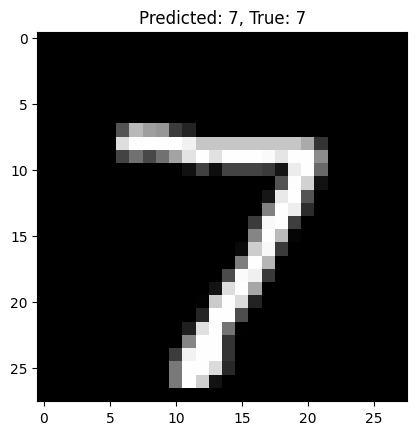

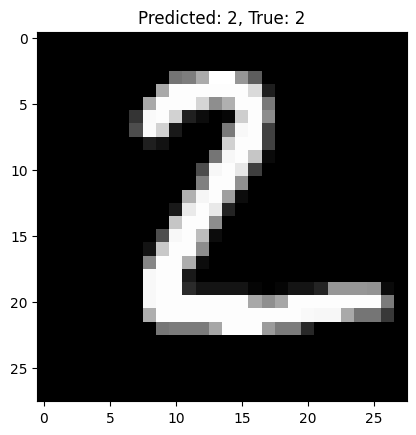

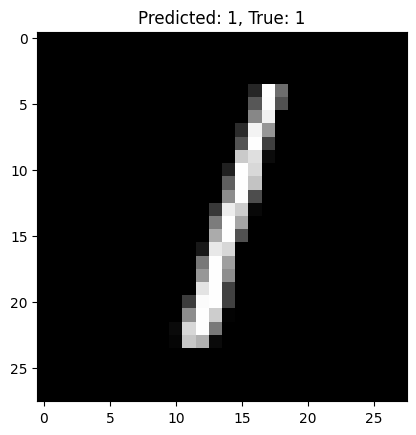

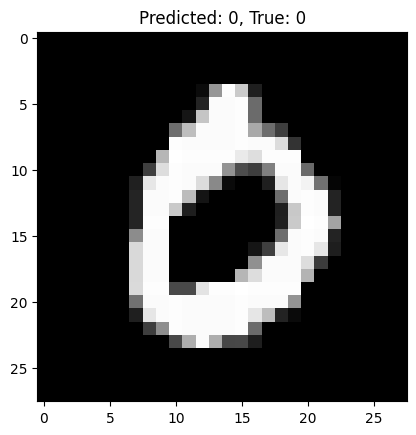

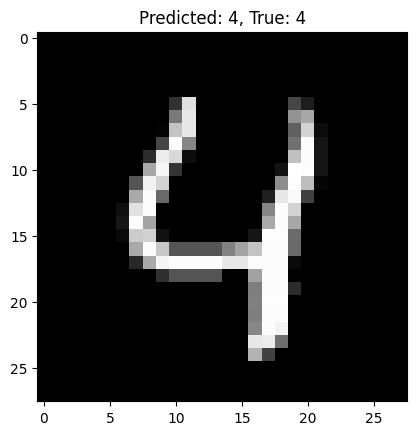

In [11]:
#predict on the few test samples
predictions=model.predict(x_test[:5])
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5],axis=1)

for i in range(5):
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title(f"Predicted: {predicted_classes[i]}, True: {true_classes[i]}")
    plt.show()